<a href="https://colab.research.google.com/github/Qweeckusha/vvsu_mml/blob/main/colab/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 5.2

По итоговому датасету:

1. Преобразовать текстовые данные (очистка + токенизация + нормализация).
2. Обучить модель **Word2Vec** на текстах.
3. Заполнить пропуски в числовых признаках через **SimpleImputer**.
4. Выбрать алгоритм **кластеризации** и построить кластеры.
5. Построить модель для **предсказания кластера** (supervised) с подбором гиперпараметров через **GridSearchCV**.


In [1]:
!pip install pymorphy3 gensim scikit-learn nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 61.1 MB/s eta 0:00:00


In [2]:
# Базовые импорты
import pandas as pd
import numpy as np


In [3]:
import sqlite3
conn = sqlite3.connect("lenta.db")
df = pd.read_sql_query("SELECT * FROM articles;", conn)
conn.close()



In [4]:
df.head()

,guid,title,description,url,published_at,comments_count,created_at_utc,rating
0,61e02531-0dfb-4c65-8f96-b4afbbd1d826,Microsoft опровергла слухи о выводе MS Points ...,"Microsoftопровергла сведения, что она собирает...",https://lenta.ru/news/2012/10/10/mspoints/,2012-10-10 15:37:00,0,2025-12-19 12:09:37,0
1,061c135a-7781-4a20-801a-4c70aa270c24,Астрономы описали симбиоз звезды и черной дыры,"Астрономы предложили гипотезу, описывающую эво...",https://lenta.ru/news/2010/10/21/binary/,2010-10-21 15:46:00,0,2025-12-19 12:09:37,0
2,3368376e-2c13-4d0f-b51c-1dddc5432352,Десятилетний мальчик пожаловался службе спасен...,Десятилетний мальчик (его имя не называется) п...,https://lenta.ru/news/2010/10/21/boy/,2010-10-21 15:21:00,0,2025-12-19 12:09:37,0
3,4bf8006c-1912-42a4-8b7f-46cc3281b018,Названы самые часто упоминаемые песни в литера...,"Песня группы The Beatles ""Hey Jude"" на данный ...",https://lenta.ru/news/2012/10/10/hey/,2012-10-10 21:16:00,0,2025-12-19 12:09:38,0
4,0d38e6dd-00ac-4976-bed7-356d52c13c6d,Промсвязьбанк отказался от народного IPO,IPO (первичное размещение акций на бирже) Пром...,https://lenta.ru/news/2012/10/10/ipo/,2012-10-10 17:15:00,0,2025-12-19 12:09:39,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   guid            99999 non-null  object
 1   title           99999 non-null  object
 2   description     99999 non-null  object
 3   url             99999 non-null  object
 4   published_at    99999 non-null  object
 5   comments_count  99999 non-null  int64 
 6   created_at_utc  99999 non-null  object
 7   rating          99999 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 6.1+ MB


## Предобработка

In [6]:
import re
import nltk
from nltk.corpus import stopwords

In [7]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
from pymorphy3 import MorphAnalyzer

In [ ]:
STOP_RU = set(stopwords.words("russian"))
TOKEN_RE = re.compile(r"[А-Яа-яA-Za-z]+", flags=re.U)
morph = MorphAnalyzer()

def preprocess_text(text: str):
    if not isinstance(text, str):
        text = "" if text is None else str(text)

    text = text.lower()
    tokens = TOKEN_RE.findall(text)

    lemmas = []
    for token in tokens:
        # Отсекаем короткий мусор 💀
        if len(token) <= 2:
            continue

        # Русские и латинские слова отдельно (иноагенты)
        if re.match(r"[а-я]", token):
            # Русское слово: нормальная форма через pymorphy3
            if token in STOP_RU:
                continue
            parsed = morph.parse(token)[0]
            lemma = parsed.normal_form
            if lemma in STOP_RU:
                continue
        else:
            # Латинское/английское слово — оставляем как есть
            lemma = token

        lemmas.append(lemma)

    return lemmas
text_col = "description"  # ваша текстовая колонка
tokenized_texts = df[text_col].astype(str).apply(preprocess_text).tolist()


In [ ]:
sample_text = df["description"].iloc[0]
print(sample_text[:100], "...")

preprocess_text(sample_text)[:100]

In [ ]:
# Уже делали выше, но для проверки нашего массива стоило выполнить
tokenized_texts[0][:40]

['резидент',
 'свободный',
 'порт',
 'планировать',
 'вложить',
 'млрд',
 'рубль',
 'строительство',
 'владивосток',
 'новый',
 'многофункциональный',
 'комплекс',
 'площадь',
 'тысяча',
 'это',
 'калин',
 'молл',
 'парковка',
 'обещать',
 'гектар',
 'соглашение',
 'крдть',
 'проект',
 'должный',
 'реализовать',
 'год',
 'однако',
 'сообщаться',
 'именно',
 'название',
 'компания',
 'новость',
 'смочь',
 'выяснить',
 'резидент',
 'также',
 'принадлежать',
 'больший',
 'продуктовый',
 'база']

## Обучение модели

In [ ]:
from gensim.models import Word2Vec
import numpy as np

w2v = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=10,
)


In [ ]:
def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

doc_vectors = np.vstack([doc_vector(t, w2v) for t in tokenized_texts])
doc_vectors.shape


(7024, 100)

In [ ]:
doc_vectors[:3]

array([[-0.16199164,  0.24666072, -0.03587332, -0.08349524,  0.04616961,
        -0.19094987,  0.06150618,  0.42473286, -0.2758117 , -0.05022216,
        -0.20183943, -0.36916265,  0.1745261 ,  0.01656048,  0.02824827,
        -0.25289056, -0.03219241, -0.26392335,  0.282923  , -0.16842133,
         0.2362408 , -0.02629378,  0.2860902 , -0.15756701,  0.11685494,
         0.11601359, -0.3435591 , -0.29602423, -0.1628793 , -0.01391034,
         0.20670499,  0.14500412,  0.01786109, -0.22714268, -0.0964741 ,
        -0.00928875,  0.09642062,  0.04845142, -0.13920681, -0.09207402,
        -0.07501656, -0.17759511, -0.03091882, -0.13981833,  0.06810887,
        -0.15445447, -0.16532768, -0.01087965,  0.20837975, -0.10150989,
         0.0283158 , -0.06002707, -0.11445633, -0.02721663, -0.15176275,
         0.14053932,  0.12929323, -0.11351888, -0.17173748, -0.09382652,
         0.06740525,  0.00402075, -0.29222253,  0.04156469, -0.04696881,
         0.19658276, -0.18302467,  0.12027278, -0.2

In [ ]:
w2v.wv.most_similar("наука", topn=10)

[('доцент', 0.7858831882476807),
 ('кафедра', 0.7165873050689697),
 ('физико', 0.7077056169509888),
 ('геология', 0.7057895064353943),
 ('овощеводство', 0.7028088569641113),
 ('фнц', 0.6979334950447083),
 ('эволюция', 0.6943235397338867),
 ('биотехнология', 0.6889738440513611),
 ('журналистика', 0.6873600482940674),
 ('вавилов', 0.6869577765464783)]

In [ ]:
for test_word in ["наука", "страна", "космос", "владивосток", "вакцина"]:
    if test_word not in w2v.wv:
        continue

    print(f"\nПохожие слова для «{test_word}»:")
    for word, score in w2v.wv.most_similar(test_word, topn=5):
        print(f"  {word:15s} {score:.3f}")


Похожие слова для «наука»:
  доцент          0.786
  кафедра         0.717
  физико          0.708
  геология        0.706
  овощеводство    0.703

Похожие слова для «страна»:
  азербайджан     0.711
  регион          0.700
  еаэс            0.698
  китай           0.695
  снг             0.692

Похожие слова для «космос»:
  трк             0.686
  театрально      0.679
  дши             0.665
  цси             0.660
  заря            0.660

Похожие слова для «владивосток»:
  город           0.690
  четверг         0.666
  вторник         0.626
  июль            0.616
  пятница         0.615

Похожие слова для «вакцина»:
  бешенство       0.764
  иммунизация     0.745
  корь            0.734
  прививка        0.723
  иммуноглобулин  0.720


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

doc_vectors_2d = pca.fit_transform(doc_vectors)
doc_vectors_2d[:15]
X_features = doc_vectors_2d

array([[-0.35736546,  0.09769555],
       [-0.28460404, -0.02102664],
       [-0.28356844,  0.05726177],
       [-0.22069556,  0.17137395],
       [-0.10744613,  0.06153049],
       [ 0.1006676 ,  0.23167676],
       [-0.29697996,  0.14346677],
       [-0.2248508 ,  0.04871127],
       [-0.30598277, -0.0219385 ],
       [-0.32063532, -0.0975692 ],
       [-0.24889663, -0.02013011],
       [ 0.01586181,  0.15244468],
       [-0.09896958,  0.00314732],
       [-0.19670278,  0.10128392],
       [ 0.00255895,  0.22081283]], dtype=float32)

In [ ]:
df_subset = df.iloc[:7024].copy()
df_subset["pca_x"] = doc_vectors_2d[:, 0]
df_subset["pca_y"] = doc_vectors_2d[:, 1]

df_subset.head()

guid  \
0  f21c47b1-d838-4aea-b4e9-d1e90a4d1d11   
1  84dd1851-5a33-496a-bffc-8c696b0dca91   
2  cfcc5ad9-0150-4984-83a2-2fa6b41a67ae   
3  26e6dbf4-8646-45a7-9241-0487f05528ee   
4  338507fe-f4ed-422e-85b3-8642559a09c3   

                                                                                               title  \
0           Торговый центр в два раза больше «Калины Молл» хотят построить на въезде в Снеговую Падь   
1             В Приморье запустят проект по возвращению студентов-высокобалльников из других городов   
2         Эвакуаторы добрались до Фонтанной: забрали две малолитражки, а Lexus успела спасти хозяйка   
3  19 километров трассы Раздольное – Хасан и подъезд к Безверхово отремонтировали в этом году (ФОТО)   
4                      На выходных на Спиридонова могут быть пробки из-за работ на сетях канализации   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## Обработка числовых признаков
Их нет

In [ ]:
# from sklearn.impute import SimpleImputer
#
# num_cols = ["comments_count", "rating"]  # числовые фичи
# numeric = df[num_cols].values
#
# imputer = SimpleImputer(strategy="median")
# numeric_imputed = imputer.fit_transform(numeric)
# numeric_imputed.shape


C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [1]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


(7024, 1)

## Кластеризация


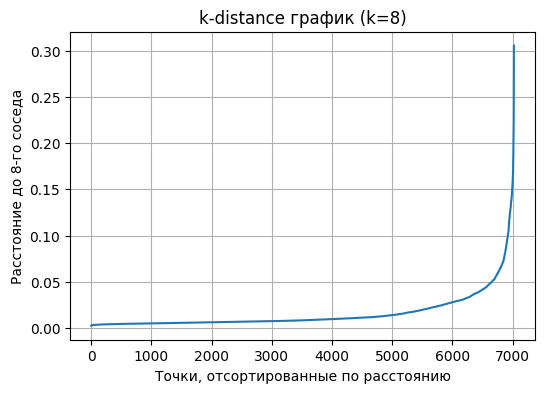

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X_for_dbscan = doc_vectors_2d  # или другие признаки
k = 8  # это min_samples

# 1–2. считаем расстояния до k-го соседа
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_for_dbscan)
distances, indices = neigh.kneighbors(X_for_dbscan)

# расстояние до k-го соседа (столбец k-1)
k_distances = np.sort(distances[:, k-1])

# 3–4. строим график
plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"k-distance график (k={k})")
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.047, min_samples=8)


cluster_labels = dbscan.fit_predict(doc_vectors_2d)

# -1 в DBSCAN означает "шум"
np.unique(cluster_labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6]),
 array([ 277, 5954,  103,  312,  338,   13,   12,   15]))

In [ ]:
df_subset["cluster"] = cluster_labels
df_subset[["title", "cluster"]].head(10)

,title,cluster
0,Торговый центр в два раза больше «Калины Молл» хотят построить на въезде в Снеговую Падь,0
1,В Приморье запустят проект по возвращению студентов-высокобалльников из других городов,0
2,"Эвакуаторы добрались до Фонтанной: забрали две малолитражки, а Lexus успела спасти хозяйка",0
3,19 километров трассы Раздольное – Хасан и подъезд к Безверхово отремонтировали в этом году (ФОТО),0
4,На выходных на Спиридонова могут быть пробки из-за работ на сетях канализации,0
5,За последнюю неделю во Владивостоке количество травм из-за гололёда выросло на 10%,0
6,«Меньше не стало»: на зиму крысы во Владивостоке перебираются из мусорок в подвалы,0
7,Детей на время ремонта крыши детского сада на Интернациональной переведут в другие учреждения,0
8,Половина решили на 0 баллов или не пришли: дистанционный этап исказил итоги всероссийской олимпиады по математике во Владивостоке,0
9,12 января предельный срок подачи уведомления о переходе на АУСН,0


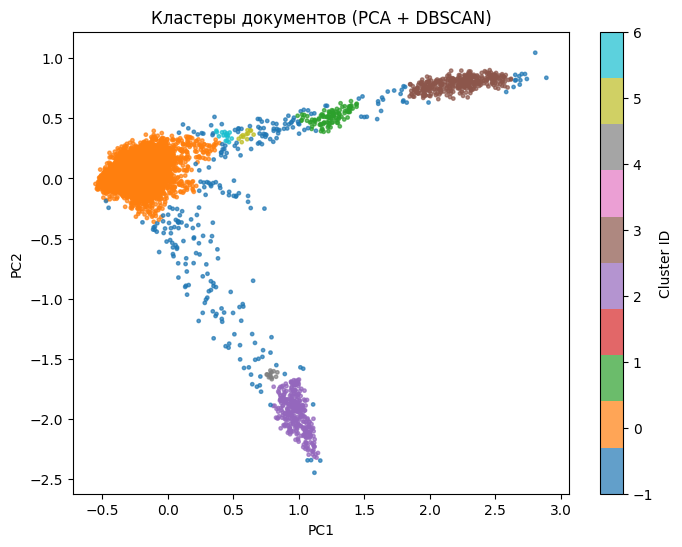

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_subset["pca_x"],
    df_subset["pca_y"],
    c=df_subset["cluster"],
    s=6,
    cmap="tab10",
    alpha=0.7,
)
plt.colorbar(scatter, label="Cluster ID")
plt.title("Кластеры документов (PCA + DBSCAN)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Предсказать кластеры методом DecisionTree

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = X_features
y = df_subset["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid_dt.fit(X_train, y_train)

print("Лучшие параметры:", grid_dt.best_params_)
print("Лучший CV accuracy:", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


## Предсказать кластеры методом KNN

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X = X_features
y = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 10, 15],
    "weights": ["uniform", "distance"],
    "metric": ["cosine"],
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV accuracy:", grid.best_score_)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
